In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
attacking_data = pd.read_csv("worldcup_2026_team_attacking_stats.csv").drop("Rank", axis=1)
defensive_data = pd.read_csv("worldcup_2026_team_defensive_stats.csv").drop("Rank", axis=1)
movement_data = pd.read_csv("worldcup_2026_team_offers_receptions_stats.csv").drop("Rank", axis=1)
passing_data = pd.read_csv("worldcup_2026_team_passing_stats.csv").drop("Rank", axis=1)
physical_data = pd.read_csv("worldcup_2026_team_physical_stats.csv").drop("Rank", axis=1)


In [4]:
merged_data = (
    attacking_data
    .merge(defensive_data, on="Team")
    .merge(movement_data, on="Team")
    .merge(passing_data, on="Team")
    .merge(physical_data, on="Team")
)


In [5]:
merged_data["xG efficiency"] = pd.to_numeric(
    merged_data["xG efficiency"].astype(str).str.replace(r"[^0-9.]", "", regex=True),
    errors="coerce"
)
if "xG efficiency" in merged_data.columns:
    merged_data = merged_data.drop("xG efficiency", axis=1)


In [6]:
merged_data.map(lambda x: isinstance(x,str)).sum()

Team                                              48
Goals                                              0
Assists                                            0
Attempts at goal                                   0
Attempts on target                                 0
Attempts off target                                0
Attempt at goal conversion rate                    0
Attempts inside the penalty area                   0
Attempts outside the penalty area                  0
Headed attempts at goal                            0
xG                                                 0
Corners                                            0
Possession control                                 0
Own goals                                          0
Goals conceded                                     0
Forced turnovers                                   0
Ball recovery time                                 0
Defensive pressures applied                        0
Defensive pressures directly applied          

In [7]:
teams_percentiles=merged_data
teams_percentiles_features=teams_percentiles.drop(['Team',],axis=1)

In [8]:
percentiles=teams_percentiles_features.rank(pct=True)*100

In [9]:
percentiles.iloc[3].sort_values(ascending=True)

Goals conceded                                      3.125000
Crossing accuracy                                  21.875000
Own goals                                          38.541667
Attempt at goal conversion rate                    39.583333
Average Speed                                      65.625000
Ball recovery time                                 87.500000
Defensive pressures directly applied               89.583333
Assists                                            89.583333
Goals                                              92.708333
Passing accuracy                                   94.791667
Switches of play accuracy                          94.791667
Defensive pressures applied                        95.833333
Take-ons completed                                 95.833333
Headed attempts at goal                            96.875000
Attempts inside the penalty area                   97.916667
Receptions in behind                               97.916667
Defensive line breaks at

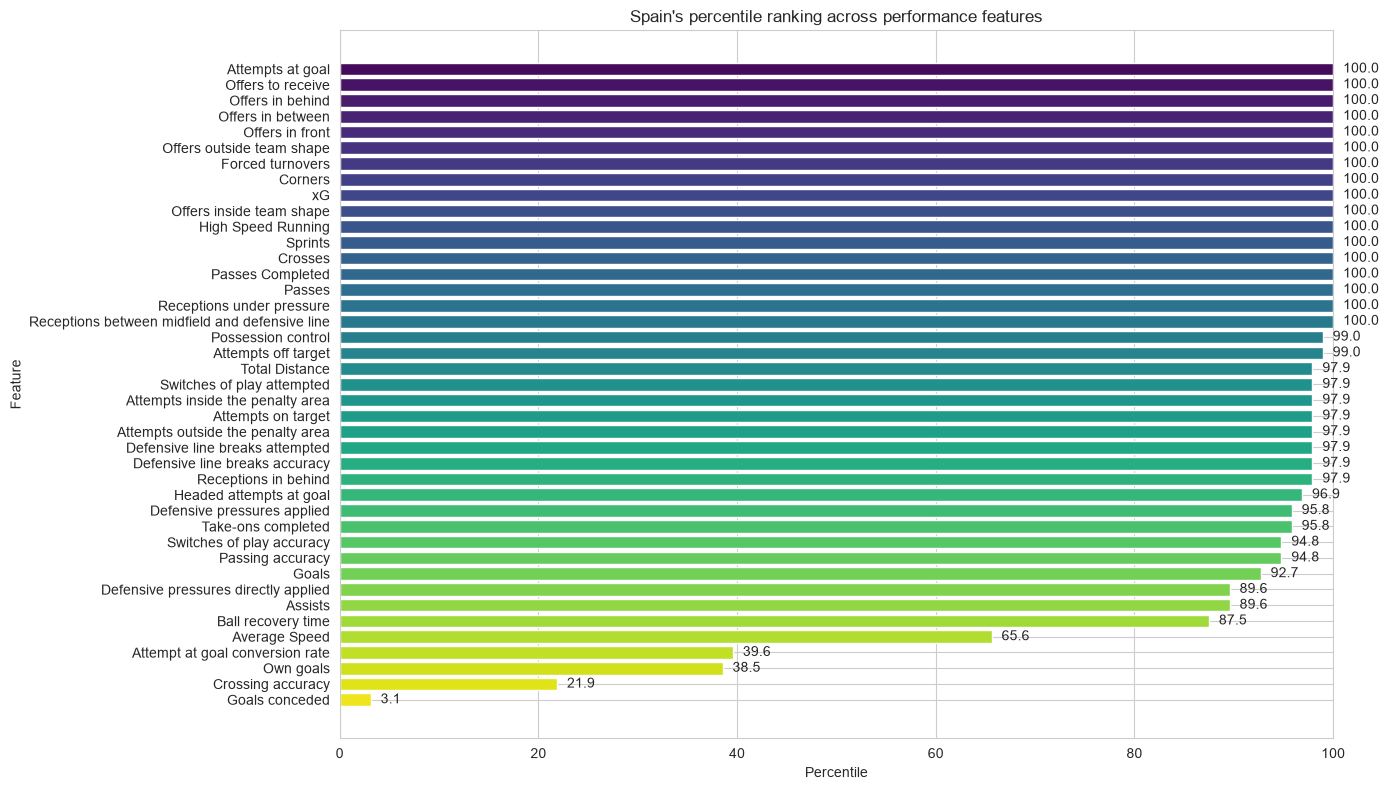

In [ ]:
sns.set_style("whitegrid")

ranked_percentiles = percentiles.loc[3].sort_values(ascending=False)

plt.figure(figsize=(14, 8))
bars = plt.barh(
    ranked_percentiles.index,
    ranked_percentiles.values,
    color=sns.color_palette("viridis", len(ranked_percentiles))
)
plt.gca().invert_yaxis()
plt.xlabel("Percentile")
plt.ylabel("Feature")
plt.title("Spain's percentile ranking across performance features")
plt.xlim(0, 100)

for bar, value in zip(bars, ranked_percentiles.values):
    plt.text(value + 1, bar.get_y() + bar.get_height() / 2, f"{value:.1f}", va="center", ha="left")

plt.tight_layout()
plt.show()

Spain better than 80 percent in almozt all my metrics except average speed,attempt at goal conversion rate and crossing accuracy that all .No much weakeness expected by the worlcup winners 